# Learning p(L_k | L_<k) in one matrix

This small tree example uses `self_row_cov=True` and an ordinary ash prior on F.
The fit learns the conditional priors and loading posteriors in the same
variational objective. There is no burn-in or chain configuration.


In [1]:
import torch
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

torch.set_num_threads(1)
torch.manual_seed(4)
n, p = 120, 60


## Simulate a parent and two children
A child is likely to activate only when the parent is active. True loadings
are used to generate observations and evaluate predictions, never to initialize fitting.


In [2]:
parent = torch.bernoulli(torch.full((n,), 0.5))
child1 = torch.bernoulli(0.1 + 0.75 * parent)
child2 = torch.bernoulli(0.1 + 0.7 * parent)
L_true = torch.stack((parent, child1, child2), 1)
F_true = torch.zeros(p, 3)
for k in range(3):
    F_true[20*k:20*(k+1), k] = 1
signal = L_true @ F_true.T
noise_sd = 0.7
Y = signal + noise_sd * torch.randn(n, p)


## Fit with one flag
The specified ordering defines potential parent relationships; it does not
identify the generating tree by itself. Here every earlier fitted loading
is a possible parent of each later loading.


In [3]:
model = cEBMF(
    Y, K=3, prior_L="cgb", prior_F="norm", self_row_cov=True,
    S=noise_sd, device="cpu",
    prior_L_kwargs={"hidden_dim": 12, "n_layers": 1, "n_epochs": 5, "penalty": 1, "lr": 0.01},
    prior_F_kwargs={"penalty": 1},
)
model.initialise_factors()
result = model.fit(maxit=8)
print(result.inference)
print("Signal RMSE:", (result.reconstruction - signal).square().mean().sqrt().item())


conditional_variational
Signal RMSE: 0.15891803801059723


## Inspect the objective
This is a numerical approximation to the negative regularized ELBO: lower is
better. Increase `conditional_kwargs={"quadrature_points": 48, "parent_samples": 64}`
to assess integration sensitivity. Numerical approximations and finite training
can cause increases; an exact coordinate-maximization guarantee is not claimed.


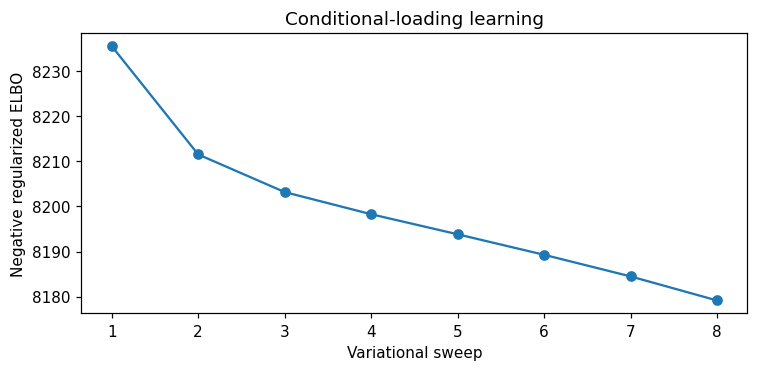

In [4]:
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, len(result.history_obj) + 1), torch.stack(result.history_obj).cpu().tolist(), marker="o")
plt.xlabel("Variational sweep")
plt.ylabel("Negative regularized ELBO")
plt.title("Conditional-loading learning")
plt.tight_layout()
plt.show()


For an independent cEBMF comparison, construct a fresh model with
`self_row_cov=False`, matched prior settings, and the same initial factors.
With no latent-covariate edges the original cEBMF solver is used directly.

For two observation matrices and missing modalities, continue with
[the ATAC-RNA example](ATAC_RNA_joint.ipynb).
